# 13 - Model × Dataset × Class Analysis

Bu notebook **yeni model eğitmez**.

Amaç, mevcut deney sonuçlarını tek bir yerde birleştirerek şu soruya cevap vermektir:

> Hangi model, hangi veri kaynağında ve hangi sınıfta güçlü/zayıf?

Ana çıktı:
- `model_dataset_class_metrics.csv`
- sınıf bazlı F1 heatmap
- dataset bazlı Macro-F1 heatmap
- neutral sınıf karşılaştırması
- model sıralamasının dataset'e göre değişimini gösteren özet

Notebook mümkün olduğunca mevcut prediction/result dosyalarını otomatik bulur. Eksik bir sonuç varsa onu uydurmaz;
bulunan sonuçlarla devam eder.


In [1]:

from thesis_utils import PROJECT_ROOT

from pathlib import Path
import re
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_recall_fscore_support,
)

try:
    from IPython.display import display
except Exception:
    display = print

warnings.filterwarnings("ignore")

LABELS = ["negative", "neutral", "positive"]

CHECKPOINT_ROOT = PROJECT_ROOT / "checkpoints" / "financial_sentiment_multi_model"
OUTPUT_DIR = CHECKPOINT_ROOT / "model_dataset_class_analysis"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Checkpoint root:", CHECKPOINT_ROOT)
print("Output dir     :", OUTPUT_DIR)


Checkpoint root: D:\serkan.kaymak\financial_sentiment_thesis\financial_sentiment_thesis\checkpoints\financial_sentiment_multi_model
Output dir     : D:\serkan.kaymak\financial_sentiment_thesis\financial_sentiment_thesis\checkpoints\financial_sentiment_multi_model\model_dataset_class_analysis


In [2]:

# ============================================================
# 1) MEVCUT PREDICTION DOSYALARINI OTOMATİK BUL
# ============================================================

def normalize_model_name(value, path_text=""):
    s = (str(value) + " " + str(path_text)).lower()

    if "distilbert" in s:
        return "DistilBERT"
    if "roberta" in s:
        return "RoBERTa"
    if "finbert" in s:
        # fine-tuned ile original ayrımı
        if "target_finetuned" in s or "multiseed" in s or "fine-tuned" in s or "fine_tuned" in s:
            return "Fine-tuned FinBERT"
        return "FinBERT"
    if "bert" in s:
        return "BERT"

    return str(value).strip() if str(value).strip() else None


def infer_dataset_name(path):
    s = str(path).lower().replace("\\", "/")

    if "sp500" in s:
        return "S&P 500"
    if "reuters" in s:
        return "Reuters"
    if "synthetic" in s:
        return "Synthetic"
    if "internal_test" in s or "/test_predictions.csv" in s:
        return "Internal"

    return None


def normalize_label_series(series):
    return series.astype(str).str.lower().str.strip()


candidate_paths = []

if CHECKPOINT_ROOT.exists():
    for pattern in [
        "*predictions*.csv",
        "*prediction*.csv",
    ]:
        candidate_paths.extend(CHECKPOINT_ROOT.rglob(pattern))

candidate_paths = sorted(set(candidate_paths))

records = []

for path in candidate_paths:
    try:
        df = pd.read_csv(path, encoding="utf-8-sig")
    except Exception:
        try:
            df = pd.read_csv(path)
        except Exception:
            continue

    cols = set(df.columns)

    gold_col = next((c for c in ["gold_label", "label", "true_label"] if c in cols), None)
    pred_col = next((c for c in ["prediction", "predicted_label", "pred_label"] if c in cols), None)

    if gold_col is None or pred_col is None or len(df) == 0:
        continue

    dataset = None
    if "dataset" in df.columns:
        dataset = str(df["dataset"].iloc[0]).strip()
    if not dataset:
        dataset = infer_dataset_name(path)

    model = None
    if "model" in df.columns:
        model = normalize_model_name(df["model"].iloc[0], path)
    else:
        model = normalize_model_name("", path)

    if dataset is None or model is None:
        continue

    # Multi-seed 123/2024 dosyalarını ana class-domain analize dahil etmiyoruz.
    # Burada ana seed=42 / tezde kullanılan temel model sonuçlarını hedefliyoruz.
    path_text = str(path).lower()
    if "multiseed" in path_text:
        continue

    records.append({
        "path": path,
        "model": model,
        "dataset": dataset,
        "n_rows": len(df),
        "gold_col": gold_col,
        "pred_col": pred_col,
    })

discovery_df = pd.DataFrame(records)

print("Otomatik bulunan uygun prediction dosyaları:")
if len(discovery_df):
    display(discovery_df.assign(path=discovery_df["path"].astype(str)))
else:
    print("Prediction dosyası bulunamadı; aşağıdaki tez referans sonuçları kullanılacak.")


Otomatik bulunan uygun prediction dosyaları:


,path,model,dataset,n_rows,gold_col,pred_col
0,D:\serkan.kaymak\financial_sentiment_thesis\fi...,Fine-tuned FinBERT,Internal,2386,gold_label,prediction


In [3]:

# ============================================================
# 2) PREDICTION DOSYALARINDAN METRİK HESAPLA
# ============================================================

def compute_metrics_from_predictions(path, model, dataset, gold_col, pred_col):
    df = pd.read_csv(path, encoding="utf-8-sig")

    y_true = normalize_label_series(df[gold_col])
    y_pred = normalize_label_series(df[pred_col])

    valid = y_true.isin(LABELS) & y_pred.isin(LABELS)
    y_true = y_true[valid].to_numpy()
    y_pred = y_pred[valid].to_numpy()

    if len(y_true) == 0:
        return None

    precision, recall, f1s, support = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=LABELS,
        average=None,
        zero_division=0,
    )

    return {
        "model": model,
        "dataset": dataset,
        "n": len(y_true),
        "accuracy": accuracy_score(y_true, y_pred),
        "f1_macro": f1_score(y_true, y_pred, labels=LABELS, average="macro", zero_division=0),
        "f1_weighted": f1_score(y_true, y_pred, labels=LABELS, average="weighted", zero_division=0),
        "precision_negative": precision[0],
        "recall_negative": recall[0],
        "f1_negative": f1s[0],
        "support_negative": int(support[0]),
        "precision_neutral": precision[1],
        "recall_neutral": recall[1],
        "f1_neutral": f1s[1],
        "support_neutral": int(support[1]),
        "precision_positive": precision[2],
        "recall_positive": recall[2],
        "f1_positive": f1s[2],
        "support_positive": int(support[2]),
        "source": "prediction_file",
        "source_path": str(path),
    }


computed_rows = []

for row in discovery_df.itertuples(index=False):
    try:
        result = compute_metrics_from_predictions(
            row.path,
            row.model,
            row.dataset,
            row.gold_col,
            row.pred_col,
        )
        if result:
            computed_rows.append(result)
    except Exception as exc:
        print("Atlandı:", row.path, "|", exc)

computed_df = pd.DataFrame(computed_rows)

if len(computed_df):
    # Aynı model-dataset için birden fazla dosya varsa ilkini al.
    computed_df = (
        computed_df
        .sort_values(["model", "dataset", "source_path"])
        .drop_duplicates(["model", "dataset"], keep="first")
        .reset_index(drop=True)
    )

display(computed_df.round(6) if len(computed_df) else pd.DataFrame())


,model,dataset,n,accuracy,f1_macro,f1_weighted,precision_negative,recall_negative,f1_negative,support_negative,precision_neutral,recall_neutral,f1_neutral,support_neutral,precision_positive,recall_positive,f1_positive,support_positive,source,source_path
0,Fine-tuned FinBERT,Internal,2386,0.881811,0.851176,0.882874,0.764103,0.832402,0.796791,358,0.930667,0.901227,0.91571,1549,0.826613,0.85595,0.841026,479,prediction_file,D:\serkan.kaymak\financial_sentiment_thesis\fi...


In [4]:

# ============================================================
# 3) TEZDEKİ MEVCUT SONUÇLARI REFERANS OLARAK EKLE
# ============================================================
# Prediction dosyası bulunmayan model-dataset çiftlerinde bu kayıtlar kullanılır.
# Bunlar mevcut tez sonuçlarıdır; yeni sonuç değildir.

reference_rows = [
    # Internal
    {"model":"FinBERT","dataset":"Internal","accuracy":0.7323,"f1_macro":0.6794,"f1_weighted":0.7400},
    {"model":"DistilBERT","dataset":"Internal","accuracy":0.8583,"f1_macro":0.8218,"f1_weighted":0.8593},
    {"model":"BERT","dataset":"Internal","accuracy":0.8722,"f1_macro":0.8378,"f1_weighted":0.8733},
    {"model":"RoBERTa","dataset":"Internal","accuracy":0.8906,"f1_macro":0.8651,"f1_weighted":0.8918},

    # S&P500 - class F1 values mevcut confusion matrixlerden doğrulanmıştı
    {"model":"FinBERT","dataset":"S&P 500","accuracy":0.7519,"f1_macro":0.7521,"f1_weighted":0.7513,
     "f1_negative":0.766328,"f1_neutral":0.748201,"f1_positive":0.741848,
     "support_negative":323,"support_neutral":339,"support_positive":398},
    {"model":"DistilBERT","dataset":"S&P 500","accuracy":0.7519,"f1_macro":0.7510,"f1_weighted":0.7525,
     "f1_negative":0.739206,"f1_neutral":0.737789,"f1_positive":0.775885,
     "support_negative":323,"support_neutral":339,"support_positive":398},
    {"model":"BERT","dataset":"S&P 500","accuracy":0.7557,"f1_macro":0.7549,"f1_weighted":0.7561,
     "f1_negative":0.744828,"f1_neutral":0.745849,"f1_positive":0.774108,
     "support_negative":323,"support_neutral":339,"support_positive":398},
    {"model":"RoBERTa","dataset":"S&P 500","accuracy":0.8132,"f1_macro":0.8145,"f1_weighted":0.8153,
     "f1_negative":0.833058,"f1_neutral":0.776750,"f1_positive":0.833773,
     "support_negative":323,"support_neutral":339,"support_positive":398},

    # Synthetic
    {"model":"FinBERT","dataset":"Synthetic","accuracy":0.9550,"f1_macro":0.9551,"f1_weighted":0.9551},
    {"model":"DistilBERT","dataset":"Synthetic","accuracy":0.9583,"f1_macro":0.9581,"f1_weighted":0.9581},
    {"model":"BERT","dataset":"Synthetic","accuracy":0.9743,"f1_macro":0.9742,"f1_weighted":0.9742},
    {"model":"RoBERTa","dataset":"Synthetic","accuracy":0.9957,"f1_macro":0.9957,"f1_weighted":0.9957},

    # Reuters
    {"model":"FinBERT","dataset":"Reuters","accuracy":0.6966,"f1_macro":0.6866,"f1_weighted":0.7016},
    {"model":"DistilBERT","dataset":"Reuters","accuracy":0.5766,"f1_macro":0.5869,"f1_weighted":0.5953},
    {"model":"BERT","dataset":"Reuters","accuracy":0.6034,"f1_macro":0.6131,"f1_weighted":0.6240},
    {"model":"RoBERTa","dataset":"Reuters","accuracy":0.6268,"f1_macro":0.6388,"f1_weighted":0.6486},
]

reference_df = pd.DataFrame(reference_rows)
reference_df["source"] = "thesis_reference"
reference_df["source_path"] = ""

# Prediction-derived sonuç varsa onu önceliklendir.
key_cols = ["model", "dataset"]

if len(computed_df):
    computed_keys = set(map(tuple, computed_df[key_cols].to_numpy()))
    reference_missing_df = reference_df[
        ~reference_df[key_cols].apply(tuple, axis=1).isin(computed_keys)
    ].copy()
    metrics_df = pd.concat([computed_df, reference_missing_df], ignore_index=True, sort=False)
else:
    metrics_df = reference_df.copy()

metrics_df = metrics_df.sort_values(["dataset", "model"]).reset_index(drop=True)

metrics_path = OUTPUT_DIR / "model_dataset_class_metrics.csv"
metrics_df.to_csv(metrics_path, index=False, encoding="utf-8-sig")

print("Birleştirilmiş sonuçlar:")
display(metrics_df.round(6))
print("Saved:", metrics_path)


Birleştirilmiş sonuçlar:


,model,dataset,n,accuracy,f1_macro,f1_weighted,precision_negative,recall_negative,f1_negative,support_negative,precision_neutral,recall_neutral,f1_neutral,support_neutral,precision_positive,recall_positive,f1_positive,support_positive,source,source_path
0,BERT,Internal,NaN,0.872200,0.837800,0.873300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,thesis_reference,
1,DistilBERT,Internal,NaN,0.858300,0.821800,0.859300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,thesis_reference,
2,FinBERT,Internal,NaN,0.732300,0.679400,0.740000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,thesis_reference,
3,Fine-tuned FinBERT,Internal,2386.0,0.881811,0.851176,0.882874,0.764103,0.832402,0.796791,358.0,0.930667,0.901227,0.915710,1549.0,0.826613,0.85595,0.841026,479.0,prediction_file,D:\serkan.kaymak\financial_sentiment_thesis\fi...
4,RoBERTa,Internal,NaN,0.890600,0.865100,0.891800,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,thesis_reference,
5,BERT,Reuters,NaN,0.603400,0.613100,0.624000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,thesis_reference,
6,DistilBERT,Reuters,NaN,0.576600,0.586900,0.595300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,thesis_reference,
7,FinBERT,Reuters,NaN,0.696600,0.686600,0.701600,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,thesis_reference,
8,RoBERTa,Reuters,NaN,0.626800,0.638800,0.648600,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,thesis_reference,
9,BERT,S&P 500,NaN,0.755700,0.754900,0.756100,NaN,NaN,0.744828,323.0,NaN,NaN,0.745849,339.0,NaN,NaN,0.774108,398.0,thesis_reference,


Saved: D:\serkan.kaymak\financial_sentiment_thesis\financial_sentiment_thesis\checkpoints\financial_sentiment_multi_model\model_dataset_class_analysis\model_dataset_class_metrics.csv


In [5]:

# ============================================================
# 4) DATASET × MODEL MACRO-F1 MATRİSİ
# ============================================================

dataset_order = ["Internal", "S&P 500", "Synthetic", "Reuters"]
model_order = ["FinBERT", "DistilBERT", "BERT", "RoBERTa", "Fine-tuned FinBERT"]

macro_matrix = (
    metrics_df
    .pivot_table(index="model", columns="dataset", values="f1_macro", aggfunc="first")
    .reindex(index=[m for m in model_order if m in metrics_df["model"].unique()])
    .reindex(columns=[d for d in dataset_order if d in metrics_df["dataset"].unique()])
)

print("Macro-F1 matrix:")
display(macro_matrix.round(4))

macro_matrix.to_csv(
    OUTPUT_DIR / "macro_f1_model_dataset_matrix.csv",
    encoding="utf-8-sig"
)


Macro-F1 matrix:


dataset,Internal,S&P 500,Synthetic,Reuters
model,,,,
FinBERT,0.6794,0.7521,0.9551,0.6866
DistilBERT,0.8218,0.7510,0.9581,0.5869
BERT,0.8378,0.7549,0.9742,0.6131
RoBERTa,0.8651,0.8145,0.9957,0.6388
Fine-tuned FinBERT,0.8512,NaN,NaN,NaN


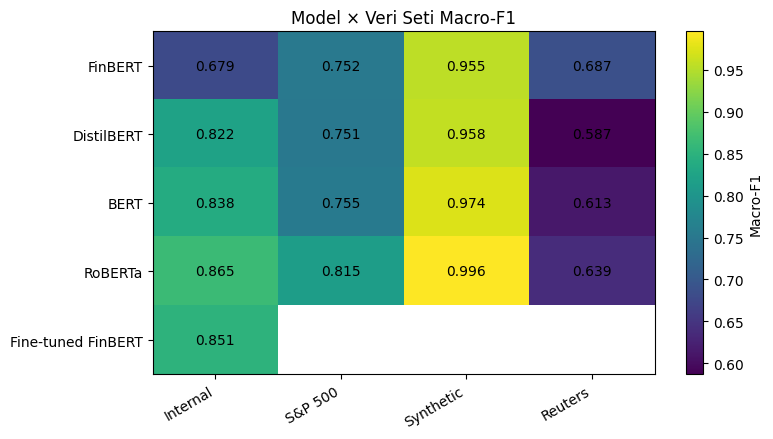

Saved: D:\serkan.kaymak\financial_sentiment_thesis\financial_sentiment_thesis\checkpoints\financial_sentiment_multi_model\model_dataset_class_analysis\macro_f1_model_dataset_heatmap.png


In [6]:

# ============================================================
# 5) MACRO-F1 HEATMAP
# matplotlib בלבד; seaborn kullanılmıyor.
# ============================================================

fig, ax = plt.subplots(figsize=(8, 4.5))

matrix = macro_matrix.to_numpy(dtype=float)
im = ax.imshow(matrix, aspect="auto")

ax.set_xticks(np.arange(len(macro_matrix.columns)))
ax.set_xticklabels(macro_matrix.columns, rotation=30, ha="right")
ax.set_yticks(np.arange(len(macro_matrix.index)))
ax.set_yticklabels(macro_matrix.index)

for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        if not np.isnan(matrix[i, j]):
            ax.text(j, i, f"{matrix[i, j]:.3f}", ha="center", va="center")

ax.set_title("Model × Veri Seti Macro-F1")
fig.colorbar(im, ax=ax, label="Macro-F1")
fig.tight_layout()

macro_heatmap_path = OUTPUT_DIR / "macro_f1_model_dataset_heatmap.png"
fig.savefig(macro_heatmap_path, dpi=220, bbox_inches="tight")
plt.show()

print("Saved:", macro_heatmap_path)


In [7]:

# ============================================================
# 6) CLASS-LEVEL F1 MATRİSİ
# Yalnızca class F1 değeri bulunan dataset/model çiftleri.
# ============================================================

class_long_rows = []

for row in metrics_df.itertuples(index=False):
    for cls in LABELS:
        value = getattr(row, f"f1_{cls}", np.nan)
        if pd.notna(value):
            class_long_rows.append({
                "model": row.model,
                "dataset": row.dataset,
                "class": cls,
                "f1": float(value),
            })

class_long_df = pd.DataFrame(class_long_rows)

if len(class_long_df):
    class_long_path = OUTPUT_DIR / "model_dataset_class_f1_long.csv"
    class_long_df.to_csv(class_long_path, index=False, encoding="utf-8-sig")

    class_long_df["column"] = (
        class_long_df["dataset"] + " | " + class_long_df["class"]
    )

    class_matrix = class_long_df.pivot_table(
        index="model",
        columns="column",
        values="f1",
        aggfunc="first",
    )

    # Daha okunaklı kolon sırası
    wanted_columns = []
    for dataset in dataset_order:
        for cls in LABELS:
            col = f"{dataset} | {cls}"
            if col in class_matrix.columns:
                wanted_columns.append(col)

    class_matrix = class_matrix.reindex(columns=wanted_columns)
    class_matrix = class_matrix.reindex(
        [m for m in model_order if m in class_matrix.index]
    )

    display(class_matrix.round(4))

    class_matrix.to_csv(
        OUTPUT_DIR / "model_dataset_class_f1_matrix.csv",
        encoding="utf-8-sig"
    )
else:
    class_matrix = pd.DataFrame()
    print("Class-level prediction/result verisi yeterli değil.")


column,Internal | negative,Internal | neutral,Internal | positive,S&P 500 | negative,S&P 500 | neutral,S&P 500 | positive
model,,,,,,
FinBERT,NaN,NaN,NaN,0.7663,0.7482,0.7418
DistilBERT,NaN,NaN,NaN,0.7392,0.7378,0.7759
BERT,NaN,NaN,NaN,0.7448,0.7458,0.7741
RoBERTa,NaN,NaN,NaN,0.8331,0.7768,0.8338
Fine-tuned FinBERT,0.7968,0.9157,0.841,NaN,NaN,NaN


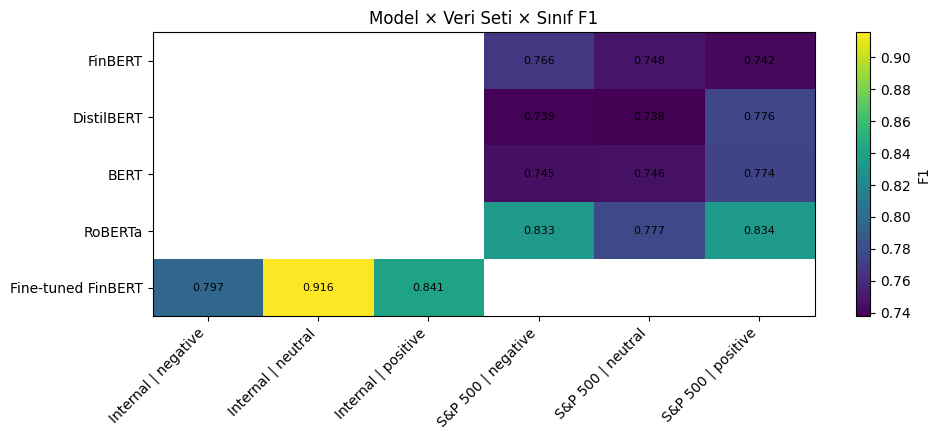

Saved: D:\serkan.kaymak\financial_sentiment_thesis\financial_sentiment_thesis\checkpoints\financial_sentiment_multi_model\model_dataset_class_analysis\model_dataset_class_f1_heatmap.png


In [8]:

# ============================================================
# 7) CLASS F1 HEATMAP
# ============================================================

if len(class_matrix):
    fig, ax = plt.subplots(figsize=(10, 4.5))

    matrix = class_matrix.to_numpy(dtype=float)
    masked = np.ma.masked_invalid(matrix)

    im = ax.imshow(masked, aspect="auto")

    ax.set_xticks(np.arange(len(class_matrix.columns)))
    ax.set_xticklabels(class_matrix.columns, rotation=45, ha="right")
    ax.set_yticks(np.arange(len(class_matrix.index)))
    ax.set_yticklabels(class_matrix.index)

    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            if not np.isnan(matrix[i, j]):
                ax.text(j, i, f"{matrix[i, j]:.3f}", ha="center", va="center", fontsize=8)

    ax.set_title("Model × Veri Seti × Sınıf F1")
    fig.colorbar(im, ax=ax, label="F1")
    fig.tight_layout()

    class_heatmap_path = OUTPUT_DIR / "model_dataset_class_f1_heatmap.png"
    fig.savefig(class_heatmap_path, dpi=220, bbox_inches="tight")
    plt.show()

    print("Saved:", class_heatmap_path)


Neutral F1 comparison:


,model,dataset,f1_neutral
3,Fine-tuned FinBERT,Internal,0.915710
12,RoBERTa,S&P 500,0.776750
11,FinBERT,S&P 500,0.748201
9,BERT,S&P 500,0.745849
10,DistilBERT,S&P 500,0.737789


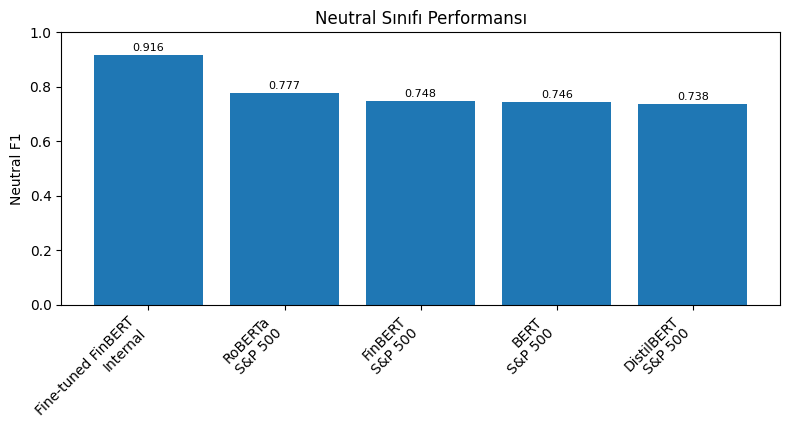

Saved: D:\serkan.kaymak\financial_sentiment_thesis\financial_sentiment_thesis\checkpoints\financial_sentiment_multi_model\model_dataset_class_analysis\neutral_f1_comparison.png


In [9]:

# ============================================================
# 8) NEUTRAL SINIFI ÖZEL ANALİZİ
# ============================================================

neutral_df = metrics_df[
    metrics_df["f1_neutral"].notna()
][["model", "dataset", "f1_neutral"]].copy()

if len(neutral_df):
    neutral_df = neutral_df.sort_values(["dataset", "f1_neutral"], ascending=[True, False])

    neutral_path = OUTPUT_DIR / "neutral_class_f1_comparison.csv"
    neutral_df.to_csv(neutral_path, index=False, encoding="utf-8-sig")

    print("Neutral F1 comparison:")
    display(neutral_df.round(6))

    fig, ax = plt.subplots(figsize=(8, 4.5))

    labels = [
        f"{r.model}\n{r.dataset}"
        for r in neutral_df.itertuples(index=False)
    ]
    values = neutral_df["f1_neutral"].to_numpy()

    ax.bar(np.arange(len(values)), values)
    ax.set_xticks(np.arange(len(values)))
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_ylabel("Neutral F1")
    ax.set_title("Neutral Sınıfı Performansı")
    ax.set_ylim(0, 1)

    for i, v in enumerate(values):
        ax.text(i, v + 0.015, f"{v:.3f}", ha="center", fontsize=8)

    fig.tight_layout()

    neutral_plot_path = OUTPUT_DIR / "neutral_f1_comparison.png"
    fig.savefig(neutral_plot_path, dpi=220, bbox_inches="tight")
    plt.show()

    print("Saved:", neutral_plot_path)
else:
    print("Neutral sınıf karşılaştırması için class-level veri bulunamadı.")


In [10]:

# ============================================================
# 9) DATASET'E GÖRE MODEL SIRALAMASI
# ============================================================

ranking_rows = []

for dataset, group in metrics_df.groupby("dataset"):
    ranked = group.sort_values("f1_macro", ascending=False).reset_index(drop=True)

    for idx, row in ranked.iterrows():
        ranking_rows.append({
            "dataset": dataset,
            "rank": idx + 1,
            "model": row["model"],
            "f1_macro": row["f1_macro"],
            "accuracy": row["accuracy"],
        })

ranking_df = pd.DataFrame(ranking_rows)

ranking_path = OUTPUT_DIR / "model_ranking_by_dataset.csv"
ranking_df.to_csv(ranking_path, index=False, encoding="utf-8-sig")

print("Dataset bazlı model sıralamaları:")
display(ranking_df.round(6))


Dataset bazlı model sıralamaları:


,dataset,rank,model,f1_macro,accuracy
0,Internal,1,RoBERTa,0.865100,0.890600
1,Internal,2,Fine-tuned FinBERT,0.851176,0.881811
2,Internal,3,BERT,0.837800,0.872200
3,Internal,4,DistilBERT,0.821800,0.858300
4,Internal,5,FinBERT,0.679400,0.732300
5,Reuters,1,FinBERT,0.686600,0.696600
6,Reuters,2,RoBERTa,0.638800,0.626800
7,Reuters,3,BERT,0.613100,0.603400
8,Reuters,4,DistilBERT,0.586900,0.576600
9,S&P 500,1,RoBERTa,0.814500,0.813200


In [11]:

# ============================================================
# 10) DOMAIN SHIFT ÖZETİ
# Internal -> external Macro-F1 değişimi
# ============================================================

internal_lookup = (
    metrics_df[metrics_df["dataset"] == "Internal"]
    .set_index("model")["f1_macro"]
    .to_dict()
)

shift_rows = []

for row in metrics_df.itertuples(index=False):
    if row.dataset == "Internal":
        continue

    if row.model not in internal_lookup:
        continue

    internal_f1 = float(internal_lookup[row.model])
    external_f1 = float(row.f1_macro)

    shift_rows.append({
        "model": row.model,
        "external_dataset": row.dataset,
        "internal_macro_f1": internal_f1,
        "external_macro_f1": external_f1,
        "delta_external_minus_internal": external_f1 - internal_f1,
        "absolute_change": abs(external_f1 - internal_f1),
    })

shift_df = pd.DataFrame(shift_rows)

shift_path = OUTPUT_DIR / "domain_shift_macro_f1_changes.csv"
shift_df.to_csv(shift_path, index=False, encoding="utf-8-sig")

print("Internal -> external Macro-F1 değişimi:")
display(shift_df.round(6))


Internal -> external Macro-F1 değişimi:


,model,external_dataset,internal_macro_f1,external_macro_f1,delta_external_minus_internal,absolute_change
0,BERT,Reuters,0.8378,0.6131,-0.2247,0.2247
1,DistilBERT,Reuters,0.8218,0.5869,-0.2349,0.2349
2,FinBERT,Reuters,0.6794,0.6866,0.0072,0.0072
3,RoBERTa,Reuters,0.8651,0.6388,-0.2263,0.2263
4,BERT,S&P 500,0.8378,0.7549,-0.0829,0.0829
5,DistilBERT,S&P 500,0.8218,0.7510,-0.0708,0.0708
6,FinBERT,S&P 500,0.6794,0.7521,0.0727,0.0727
7,RoBERTa,S&P 500,0.8651,0.8145,-0.0506,0.0506
8,BERT,Synthetic,0.8378,0.9742,0.1364,0.1364
9,DistilBERT,Synthetic,0.8218,0.9581,0.1363,0.1363


In [12]:

# ============================================================
# 11) OTOMATİK KISA BULGU ÖZETİ
# ============================================================

summary_lines = []

for dataset in dataset_order:
    g = metrics_df[metrics_df["dataset"] == dataset].dropna(subset=["f1_macro"])
    if len(g) == 0:
        continue

    best = g.sort_values("f1_macro", ascending=False).iloc[0]
    worst = g.sort_values("f1_macro", ascending=True).iloc[0]

    summary_lines.append(
        f"{dataset}: en yüksek Macro-F1 = {best['model']} ({best['f1_macro']:.4f}); "
        f"en düşük = {worst['model']} ({worst['f1_macro']:.4f})."
    )

if len(neutral_df):
    best_neutral = neutral_df.sort_values("f1_neutral", ascending=False).iloc[0]
    worst_neutral = neutral_df.sort_values("f1_neutral", ascending=True).iloc[0]

    summary_lines.append(
        f"Neutral sınıfında bulunan sonuçlar içinde en yüksek F1 = "
        f"{best_neutral['model']} / {best_neutral['dataset']} ({best_neutral['f1_neutral']:.4f}); "
        f"en düşük = {worst_neutral['model']} / {worst_neutral['dataset']} ({worst_neutral['f1_neutral']:.4f})."
    )

summary_text = "\n".join(summary_lines)

summary_txt_path = OUTPUT_DIR / "automatic_findings_summary.txt"
summary_txt_path.write_text(summary_text, encoding="utf-8")

print(summary_text)
print("\nSaved:", summary_txt_path)


Internal: en yüksek Macro-F1 = RoBERTa (0.8651); en düşük = FinBERT (0.6794).
S&P 500: en yüksek Macro-F1 = RoBERTa (0.8145); en düşük = DistilBERT (0.7510).
Synthetic: en yüksek Macro-F1 = RoBERTa (0.9957); en düşük = FinBERT (0.9551).
Reuters: en yüksek Macro-F1 = FinBERT (0.6866); en düşük = DistilBERT (0.5869).
Neutral sınıfında bulunan sonuçlar içinde en yüksek F1 = Fine-tuned FinBERT / Internal (0.9157); en düşük = DistilBERT / S&P 500 (0.7378).

Saved: D:\serkan.kaymak\financial_sentiment_thesis\financial_sentiment_thesis\checkpoints\financial_sentiment_multi_model\model_dataset_class_analysis\automatic_findings_summary.txt


## Bana göndermen gerekenler

Notebook tamamlanınca en az şu dosyaları yükle:

- `model_dataset_class_analysis/model_dataset_class_metrics.csv`
- `model_dataset_class_analysis/model_ranking_by_dataset.csv`
- `model_dataset_class_analysis/domain_shift_macro_f1_changes.csv`
- `model_dataset_class_analysis/model_dataset_class_f1_matrix.csv` *(oluştuysa)*

Grafikleri de sakla:

- `macro_f1_model_dataset_heatmap.png`
- `model_dataset_class_f1_heatmap.png`
- `neutral_f1_comparison.png`

Bu notebook **training yapmadığı için hızlı çalışmalıdır**.
